# **Tech Challenge - Fase 4: Inteligência Artificial na Triagem e Diagnóstico Clínico de Obesidade**

A obesidade é uma condição de saúde multifatorial e crônica, caracterizada pelo acúmulo excessivo de gordura corporal, atuando como fator de risco central para diversas patologias cardiovasculares e metabólicas. Em um cenário hospitalar, a capacidade de identificar precocemente os perfis de risco dos pacientes a partir de hábitos comportamentais e heranças genéticas permite intervenções preventivas mais eficazes, otimizando o fluxo de atendimento e reduzindo custos operacionais de longo prazo.

Este projeto consolida o desenvolvimento de uma **Pipeline de Machine Learning ponta a ponta**, com o objetivo de munir a equipe médica de uma ferramenta de alta confiabilidade analítica para dar suporte ao diagnóstico.

---

## **1. Extração de Dados (Extract)**
Nesta primeira etapa, realizamos o carregamento da base histórica de pacientes (`Obesity.csv`). O ecossistema inicial de dados compreende registros de variáveis demográficas, métricas biométricas brutas e indicadores de rotina de vida cotidianas (alimentação, sedentarismo e transporte).

In [4]:
import pandas as pd
import numpy as np
from google.colab import files

In [5]:
# --- 1. EXTRACT (Extração) ---
# Lendo a base oficial do desafio
try:
    df = pd.read_csv('Obesity.csv')
    print("Sucesso: Base carregada!")
except FileNotFoundError:
    print("Erro: O arquivo Obesity.csv não foi encontrado na aba 'Files'.")

Sucesso: Base carregada!


In [6]:
# Lendo o arquivo o df
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

## **2. Limpeza e Tradução (Transform - Internacionalização da Base)**
Para garantir a usabilidade prática da ferramenta e aproximar os dados do vocabulário corporativo e clínico do hospital, realizamos uma etapa de padronização nominal.

As variáveis originais em inglês foram mapeadas e traduzidas para o português, tanto na estrutura de colunas do DataFrame quanto no conteúdo interno das respostas textuais. Esse processo mitiga erros de interpretação conceitual e estabelece as fundações para que o painel analítico subsequente e a interface com o médico operem de forma clara e ágil.

In [8]:
# Criando um dicionário de mapeamento (De -> Para)
traducao_colunas = {
    'Gender': 'genero',
    'Age': 'idade',
    'Height': 'altura',
    'Weight': 'peso',
    'family_history': 'historico_familiar',
    'FAVC': 'frequencia_alimentos_caloricos',
    'FCVC': 'frequencia_vegetais',
    'NCP': 'numero_refeicoes',
    'CAEC': 'alimentos_entre_refeicoes',
    'SMOKE': 'fumante',
    'CH2O': 'consumo_agua',
    'SCC': 'monitora_calorias',
    'FAF': 'frequencia_atividade_fisica',
    'TUE': 'tempo_de_tela',
    'CALC': 'consumo_alcool',
    'MTRANS': 'meio_de_transporte',
    'Obesity': 'classificacao_obesidade'
}

# Renomeando as colunas
df.rename(columns=traducao_colunas, inplace=True)

# Visualizando o resultado
print("Colunas traduzidas com sucesso!")
print(df.columns.tolist())
display(df.head(2))

Colunas traduzidas com sucesso!
['genero', 'idade', 'altura', 'peso', 'historico_familiar', 'frequencia_alimentos_caloricos', 'frequencia_vegetais', 'numero_refeicoes', 'alimentos_entre_refeicoes', 'fumante', 'consumo_agua', 'monitora_calorias', 'frequencia_atividade_fisica', 'tempo_de_tela', 'consumo_alcool', 'meio_de_transporte', 'classificacao_obesidade']


,genero,idade,altura,peso,historico_familiar,frequencia_alimentos_caloricos,frequencia_vegetais,numero_refeicoes,alimentos_entre_refeicoes,fumante,consumo_agua,monitora_calorias,frequencia_atividade_fisica,tempo_de_tela,consumo_alcool,meio_de_transporte,classificacao_obesidade
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight


In [9]:
# 1. Criando os dicionários de mapeamento para os registros
mapeamentos = {
    'genero': {'Female': 'Feminino', 'Male': 'Masculino'},
    'historico_familiar': {'yes': 'Sim', 'no': 'Não'},
    'frequencia_alimentos_caloricos': {'yes': 'Sim', 'no': 'Não'},
    'alimentos_entre_refeicoes': {'no': 'Não', 'Sometimes': 'Às vezes', 'Frequently': 'Frequentemente', 'Always': 'Sempre'},
    'fumante': {'yes': 'Sim', 'no': 'Não'},
    'monitora_calorias': {'yes': 'Sim', 'no': 'Não'},
    'consumo_alcool': {'no': 'Não', 'Sometimes': 'Às vezes', 'Frequently': 'Frequentemente', 'Always': 'Sempre'},
    'meio_de_transporte': {
        'Public_Transportation': 'Transporte Público',
        'Automobile': 'Automóvel',
        'Walking': 'Caminhada',
        'Motorbike': 'Motocicleta',
        'Bike': 'Bicicleta'
    },
    'classificacao_obesidade': {
        'Insufficient_Weight': 'Abaixo do Peso',
        'Normal_Weight': 'Peso Normal',
        'Overweight_Level_I': 'Sobrepeso Grau I',
        'Overweight_Level_II': 'Sobrepeso Grau II',
        'Obesity_Type_I': 'Obesidade Grau I',
        'Obesity_Type_II': 'Obesidade Grau II',
        'Obesity_Type_III': 'Obesidade Grau III'
    }
}

# 2. Aplicando a tradução linha a linha
for coluna, valores in mapeamentos.items():
    if coluna in df.columns:
        df[coluna] = df[coluna].replace(valores)

# 3. Verificando o resultado
print("Tradução dos registros concluída!")
display(df.head())

Tradução dos registros concluída!


,genero,idade,altura,peso,historico_familiar,frequencia_alimentos_caloricos,frequencia_vegetais,numero_refeicoes,alimentos_entre_refeicoes,fumante,consumo_agua,monitora_calorias,frequencia_atividade_fisica,tempo_de_tela,consumo_alcool,meio_de_transporte,classificacao_obesidade
0,Feminino,21.0,1.62,64.0,Sim,Não,2.0,3.0,Às vezes,Não,2.0,Não,0.0,1.0,Não,Transporte Público,Peso Normal
1,Feminino,21.0,1.52,56.0,Sim,Não,3.0,3.0,Às vezes,Sim,3.0,Sim,3.0,0.0,Às vezes,Transporte Público,Peso Normal
2,Masculino,23.0,1.80,77.0,Sim,Não,2.0,3.0,Às vezes,Não,2.0,Não,2.0,1.0,Frequentemente,Transporte Público,Peso Normal
3,Masculino,27.0,1.80,87.0,Não,Não,3.0,3.0,Às vezes,Não,2.0,Não,2.0,0.0,Frequentemente,Caminhada,Sobrepeso Grau I
4,Masculino,22.0,1.78,89.8,Não,Não,2.0,1.0,Às vezes,Não,2.0,Não,0.0,0.0,Às vezes,Transporte Público,Sobrepeso Grau II


## **3. Engenharia de Atributos e Refinamento de Precisão**
Nesta fase, aplicamos técnicas de engenharia de recursos para extrair o máximo valor preditivo das medições brutas:

* **Derivação do IMC:** Substituímos os valores isolados de peso e altura pelo cálculo matemático do Índice de Massa Corporal (IMC), que correlaciona de forma linear e padronizada a composição física do indivíduo.
* **Tratamento de Precisão:** Variáveis de frequência que apresentavam frações flutuantes (oriundas de processos anteriores de interpolação de dados ou coletas dinâmicas) foram normalizadas e arredondadas para números inteiros ou duas casas decimais, asseverando a integridade estatística dos dados.

In [10]:
df['imc'] = (df['peso'] / (df['altura'] ** 2)).round(2)
df.drop(columns=['peso', 'altura'], inplace=True)

In [11]:
df.head(20)

,genero,idade,historico_familiar,frequencia_alimentos_caloricos,frequencia_vegetais,numero_refeicoes,alimentos_entre_refeicoes,fumante,consumo_agua,monitora_calorias,frequencia_atividade_fisica,tempo_de_tela,consumo_alcool,meio_de_transporte,classificacao_obesidade,imc
0,Feminino,21.0,Sim,Não,2.0,3.0,Às vezes,Não,2.0,Não,0.0,1.0,Não,Transporte Público,Peso Normal,24.39
1,Feminino,21.0,Sim,Não,3.0,3.0,Às vezes,Sim,3.0,Sim,3.0,0.0,Às vezes,Transporte Público,Peso Normal,24.24
2,Masculino,23.0,Sim,Não,2.0,3.0,Às vezes,Não,2.0,Não,2.0,1.0,Frequentemente,Transporte Público,Peso Normal,23.77
3,Masculino,27.0,Não,Não,3.0,3.0,Às vezes,Não,2.0,Não,2.0,0.0,Frequentemente,Caminhada,Sobrepeso Grau I,26.85
4,Masculino,22.0,Não,Não,2.0,1.0,Às vezes,Não,2.0,Não,0.0,0.0,Às vezes,Transporte Público,Sobrepeso Grau II,28.34
5,Masculino,29.0,Não,Sim,2.0,3.0,Às vezes,Não,2.0,Não,0.0,0.0,Às vezes,Automóvel,Peso Normal,20.20
6,Feminino,23.0,Sim,Sim,3.0,3.0,Às vezes,Não,2.0,Não,1.0,0.0,Às vezes,Motocicleta,Peso Normal,24.44
7,Masculino,22.0,Não,Não,2.0,3.0,Às vezes,Não,2.0,Não,3.0,0.0,Às vezes,Transporte Público,Peso Normal,19.71
8,Masculino,24.0,Sim,Sim,3.0,3.0,Às vezes,Não,2.0,Não,1.0,1.0,Frequentemente,Transporte Público,Peso Normal,20.20
9,Masculino,22.0,Sim,Sim,2.0,3.0,Às vezes,Não,2.0,Não,1.0,1.0,Não,Transporte Público,Peso Normal,22.99


## **4. Codificação de Variáveis (Feature Encoding)**
Modelos matemáticos necessitam que inputs categóricos textuais sejam transformados em representações numéricas estruturadas. Para não enviesar o algoritmo, aplicamos diferentes abordagens com base na semântica de cada atributo:

1.  **Mapeamento Binário:** Transposição de variáveis dicotômicas (como gênero e respostas sim/não) diretamente para a escala de 0 e 1.
2.  **Mapeamento Ordinal:** Variáveis com clara hierarquia de intensidade (frequência de consumo de álcool e alimentação fora de hora) foram convertidas seguindo uma progressão lógica de impacto.
3.  **Abordagem de Negócio (Transporte Ativo):** Para a coluna de locomoção, criamos uma nova métrica agrupando os modais em *Passivo* (carro/transporte público) e *Ativo* (caminhada/bicicleta), permitindo ao modelo mensurar o gasto calórico indireto de rotina do paciente.
4.  **Label Encoding do Alvo:** Estruturação das categorias de peso da variável alvo em uma régua de 0 a 6, cobrindo o espectro desde o baixo peso até a obesidade mórbida móvel.

In [12]:
# 1. Identificar quais colunas são do tipo 'object' (texto)
colunas_categoricas = df.select_dtypes(include=['object']).columns

print("--- Valores únicos por coluna ---")
for col in colunas_categoricas:
    print(f"\nColuna: {col}")
    # Mostra os valores únicos e a quantidade de vezes que aparecem
    print(df[col].value_counts())
    print("-" * 30)

--- Valores únicos por coluna ---

Coluna: genero
genero
Masculino    1068
Feminino     1043
Name: count, dtype: int64
------------------------------

Coluna: historico_familiar
historico_familiar
Sim    1726
Não     385
Name: count, dtype: int64
------------------------------

Coluna: frequencia_alimentos_caloricos
frequencia_alimentos_caloricos
Sim    1866
Não     245
Name: count, dtype: int64
------------------------------

Coluna: alimentos_entre_refeicoes
alimentos_entre_refeicoes
Às vezes          1765
Frequentemente     242
Sempre              53
Não                 51
Name: count, dtype: int64
------------------------------

Coluna: fumante
fumante
Não    2067
Sim      44
Name: count, dtype: int64
------------------------------

Coluna: monitora_calorias
monitora_calorias
Não    2015
Sim      96
Name: count, dtype: int64
------------------------------

Coluna: consumo_alcool
consumo_alcool
Às vezes          1401
Não                639
Frequentemente      70
Sempre              

In [13]:
# Tratando as casas decimais excessivas
# Arredondando colunas que representam contagens ou frequências para INTEIROS
colunas_para_inteiros = [
    'idade',
    'frequencia_vegetais',
    'numero_refeicoes',
    'frequencia_atividade_fisica',
    'tempo_de_tela'
]

for col in colunas_para_inteiros:
    if col in df.columns:
        # Usamos o round(0) e convertemos para int para remover o .0
        df[col] = df[col].round(0).astype(int)

# 3. Arredondando colunas de medição para 2 casas decimais (Altura, Peso, Água, IMC)
colunas_ajuste_decimal = ['altura', 'peso', 'consumo_agua', 'imc']

for col in colunas_ajuste_decimal:
    if col in df.columns:
        df[col] = df[col].round(2)

print("Ajustes de nomenclatura e precisão numérica concluídos!")
display(df.head())

Ajustes de nomenclatura e precisão numérica concluídos!


,genero,idade,historico_familiar,frequencia_alimentos_caloricos,frequencia_vegetais,numero_refeicoes,alimentos_entre_refeicoes,fumante,consumo_agua,monitora_calorias,frequencia_atividade_fisica,tempo_de_tela,consumo_alcool,meio_de_transporte,classificacao_obesidade,imc
0,Feminino,21,Sim,Não,2,3,Às vezes,Não,2.0,Não,0,1,Não,Transporte Público,Peso Normal,24.39
1,Feminino,21,Sim,Não,3,3,Às vezes,Sim,3.0,Sim,3,0,Às vezes,Transporte Público,Peso Normal,24.24
2,Masculino,23,Sim,Não,2,3,Às vezes,Não,2.0,Não,2,1,Frequentemente,Transporte Público,Peso Normal,23.77
3,Masculino,27,Não,Não,3,3,Às vezes,Não,2.0,Não,2,0,Frequentemente,Caminhada,Sobrepeso Grau I,26.85
4,Masculino,22,Não,Não,2,1,Às vezes,Não,2.0,Não,0,0,Às vezes,Transporte Público,Sobrepeso Grau II,28.34


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   genero                          2111 non-null   object 
 1   idade                           2111 non-null   int64  
 2   historico_familiar              2111 non-null   object 
 3   frequencia_alimentos_caloricos  2111 non-null   object 
 4   frequencia_vegetais             2111 non-null   int64  
 5   numero_refeicoes                2111 non-null   int64  
 6   alimentos_entre_refeicoes       2111 non-null   object 
 7   fumante                         2111 non-null   object 
 8   consumo_agua                    2111 non-null   float64
 9   monitora_calorias               2111 non-null   object 
 10  frequencia_atividade_fisica     2111 non-null   int64  
 11  tempo_de_tela                   2111 non-null   int64  
 12  consumo_alcool                  21

In [15]:
print("--- Avaliação de Todos os Valores Únicos (DF Limpo) ---")

# Iteramos por todas as colunas do DataFrame, sem filtrar por tipo
for col in df.columns:
    print(f"\nColuna: {col.upper()}")
    print(f"Tipo de dado: {df[col].dtype}")

    # Se a coluna tiver muitos valores diferentes (como peso ou imc),
    # mostramos apenas os 5 mais frequentes para não poluir a tela
    if df[col].nunique() > 15:
        print(f"Total de valores únicos: {df[col].nunique()}")
        print("Top 5 valores mais frequentes:")
        print(df[col].value_counts().head(5))
    else:
        # Se tiver poucos valores (como gênero ou fumante), mostra todos
        print(df[col].value_counts())

    print("-" * 35)

--- Avaliação de Todos os Valores Únicos (DF Limpo) ---

Coluna: GENERO
Tipo de dado: object
genero
Masculino    1068
Feminino     1043
Name: count, dtype: int64
-----------------------------------

Coluna: IDADE
Tipo de dado: int64
Total de valores únicos: 40
Top 5 valores mais frequentes:
idade
21    236
23    218
26    213
18    212
19    169
Name: count, dtype: int64
-----------------------------------

Coluna: HISTORICO_FAMILIAR
Tipo de dado: object
historico_familiar
Sim    1726
Não     385
Name: count, dtype: int64
-----------------------------------

Coluna: FREQUENCIA_ALIMENTOS_CALORICOS
Tipo de dado: object
frequencia_alimentos_caloricos
Sim    1866
Não     245
Name: count, dtype: int64
-----------------------------------

Coluna: FREQUENCIA_VEGETAIS
Tipo de dado: int64
frequencia_vegetais
2    1013
3     996
1     102
Name: count, dtype: int64
-----------------------------------

Coluna: NUMERO_REFEICOES
Tipo de dado: int64
numero_refeicoes
3    1470
1     316
2     176
4   

In [16]:
df.describe()

,idade,frequencia_vegetais,numero_refeicoes,consumo_agua,frequencia_atividade_fisica,tempo_de_tela,imc
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.315964,2.423496,2.687826,2.008053,1.006632,0.664614,29.700137
std,6.357078,0.583905,0.809680,0.612950,0.895462,0.674009,8.011354
min,14.000000,1.000000,1.000000,1.000000,0.000000,0.000000,13.000000
25%,20.000000,2.000000,3.000000,1.585000,0.000000,0.000000,24.325000
50%,23.000000,2.000000,3.000000,2.000000,1.000000,1.000000,28.720000
75%,26.000000,3.000000,3.000000,2.480000,2.000000,1.000000,36.015000
max,61.000000,3.000000,4.000000,3.000000,3.000000,2.000000,50.810000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   genero                          2111 non-null   object 
 1   idade                           2111 non-null   int64  
 2   historico_familiar              2111 non-null   object 
 3   frequencia_alimentos_caloricos  2111 non-null   object 
 4   frequencia_vegetais             2111 non-null   int64  
 5   numero_refeicoes                2111 non-null   int64  
 6   alimentos_entre_refeicoes       2111 non-null   object 
 7   fumante                         2111 non-null   object 
 8   consumo_agua                    2111 non-null   float64
 9   monitora_calorias               2111 non-null   object 
 10  frequencia_atividade_fisica     2111 non-null   int64  
 11  tempo_de_tela                   2111 non-null   int64  
 12  consumo_alcool                  21

In [18]:
from google.colab import files

# Salvando o DataFrame atualizado em um arquivo CSV no ambiente do Colab
nome_arquivo_final = 'base_obesidade_limpa.csv'
df.to_csv(nome_arquivo_final, index=False, encoding='utf-8-sig')

# Baixando o arquivo para máquina local
files.download(nome_arquivo_final)

print(f"O download do arquivo '{nome_arquivo_final}' foi iniciado!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

O download do arquivo 'base_obesidade_limpa.csv' foi iniciado!


In [19]:
# 1. MAPEAMENTO BINÁRIO (0 e 1)
# Criando dicionários para Sim/Não e Gênero
map_sim_nao = {'Sim': 1, 'Não': 0}
map_genero = {'Masculino': 1, 'Feminino': 0}

colunas_binarias = [
    'historico_familiar',
    'frequencia_alimentos_caloricos',
    'fumante',
    'monitora_calorias'
]

for col in colunas_binarias:
    df[col] = df[col].map(map_sim_nao)

df['genero'] = df['genero'].map(map_genero)

In [20]:
# 2. MAPEAMENTO ORDINAL (Escala de Intensidade)
# Alimentos entre refeições e álcool têm uma ordem clara de frequência
map_frequencia = {
    'Não': 0,
    'Às vezes': 1,
    'Frequentemente': 2,
    'Sempre': 3
}

df['alimentos_entre_refeicoes'] = df['alimentos_entre_refeicoes'].map(map_frequencia)
df['consumo_alcool'] = df['consumo_alcool'].map(map_frequencia)

In [22]:
df.head()

,genero,idade,historico_familiar,frequencia_alimentos_caloricos,frequencia_vegetais,numero_refeicoes,alimentos_entre_refeicoes,fumante,consumo_agua,monitora_calorias,frequencia_atividade_fisica,tempo_de_tela,consumo_alcool,meio_de_transporte,classificacao_obesidade,imc
0,0,21,1,0,2,3,1,0,2.0,0,0,1,0,Transporte Público,Peso Normal,24.39
1,0,21,1,0,3,3,1,1,3.0,1,3,0,1,Transporte Público,Peso Normal,24.24
2,1,23,1,0,2,3,1,0,2.0,0,2,1,2,Transporte Público,Peso Normal,23.77
3,1,27,0,0,3,3,1,0,2.0,0,2,0,2,Caminhada,Sobrepeso Grau I,26.85
4,1,22,0,0,2,1,1,0,2.0,0,0,0,1,Transporte Público,Sobrepeso Grau II,28.34


In [23]:
# 4. LABEL ENCODING PARA A VARIÁVEL ALVO (classificacao_obesidade)
# Vamos atribuir números de 0 a 6 para as categorias de peso
# Seguiremos a ordem lógica de peso para ajudar o modelo
map_alvo = {
    'Abaixo do Peso': 0,
    'Peso Normal': 1,
    'Sobrepeso Grau I': 2,
    'Sobrepeso Grau II': 3,
    'Obesidade Grau I': 4,
    'Obesidade Grau II': 5,
    'Obesidade Grau III': 6
}

df['classificacao_obesidade'] = df['classificacao_obesidade'].map(map_alvo)

In [24]:
# 1. Definindo a lógica de agrupamento
# 0 = Passivo (Transporte Público, Automóvel, Motocicleta)
# 1 = Ativo (Caminhada, Bicicleta)

mapeamento_transporte = {
    'Transporte Público': 0,
    'Automóvel': 0,
    'Motocicleta': 0,
    'Caminhada': 1,
    'Bicicleta': 1
}

# 2. Criando a nova coluna e removendo a antiga (opcional)
df['transporte_ativo'] = df['meio_de_transporte'].map(mapeamento_transporte)

# 3. Verificando se a transformação funcionou
print("Nova coluna 'transporte_ativo' criada!")
print(df[['meio_de_transporte', 'transporte_ativo']].value_counts())

Nova coluna 'transporte_ativo' criada!
meio_de_transporte  transporte_ativo
Transporte Público  0                   1580
Automóvel           0                    457
Caminhada           1                     56
Motocicleta         0                     11
Bicicleta           1                      7
Name: count, dtype: int64


In [25]:
df.head()

,genero,idade,historico_familiar,frequencia_alimentos_caloricos,frequencia_vegetais,numero_refeicoes,alimentos_entre_refeicoes,fumante,consumo_agua,monitora_calorias,frequencia_atividade_fisica,tempo_de_tela,consumo_alcool,meio_de_transporte,classificacao_obesidade,imc,transporte_ativo
0,0,21,1,0,2,3,1,0,2.0,0,0,1,0,Transporte Público,1,24.39,0
1,0,21,1,0,3,3,1,1,3.0,1,3,0,1,Transporte Público,1,24.24,0
2,1,23,1,0,2,3,1,0,2.0,0,2,1,2,Transporte Público,1,23.77,0
3,1,27,0,0,3,3,1,0,2.0,0,2,0,2,Caminhada,2,26.85,1
4,1,22,0,0,2,1,1,0,2.0,0,0,0,1,Transporte Público,3,28.34,0


In [26]:
df.drop(columns=['meio_de_transporte'], inplace=True)
df.head()

,genero,idade,historico_familiar,frequencia_alimentos_caloricos,frequencia_vegetais,numero_refeicoes,alimentos_entre_refeicoes,fumante,consumo_agua,monitora_calorias,frequencia_atividade_fisica,tempo_de_tela,consumo_alcool,classificacao_obesidade,imc,transporte_ativo
0,0,21,1,0,2,3,1,0,2.0,0,0,1,0,1,24.39,0
1,0,21,1,0,3,3,1,1,3.0,1,3,0,1,1,24.24,0
2,1,23,1,0,2,3,1,0,2.0,0,2,1,2,1,23.77,0
3,1,27,0,0,3,3,1,0,2.0,0,2,0,2,2,26.85,1
4,1,22,0,0,2,1,1,0,2.0,0,0,0,1,3,28.34,0


In [27]:
# 1. Primeiro, salvamos o DataFrame atualizado em um arquivo CSV no ambiente do Colab
nome_arquivo_final = 'base_obesidade_encod.csv'
df.to_csv(nome_arquivo_final, index=False, encoding='utf-8-sig')

# 2. Comando para baixar o arquivo para sua máquina local
files.download(nome_arquivo_final)

print(f"O download do arquivo '{nome_arquivo_final}' foi iniciado!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

O download do arquivo 'base_obesidade_encod.csv' foi iniciado!


## **5. Análise Exploratória e Análise do Viés de Relato**
A análise da matriz de correlação revelou um fenômeno estatístico de extrema relevância para a governança médica: o **Viés de Relato por Desejo de Aceitação Social**.

Ao cruzarmos o hábito de se alimentar entre as refeições (`alimentos_entre_refeicoes`) com os graus avançados de obesidade, o modelo matemático registrou uma correlação inesperadamente negativa. A investigação profunda por meio de distribuições visuais revelou um "achatamento" nas respostas de pacientes nos graus de Obesidade I, II e III, que reportam de forma quase unânime um consumo apenas "ocasional" (travados no valor 1).

**Insight Clínico:** Esse padrão evidencia uma distorção subjetiva nos questionários de anamnese tradicionais, onde o estigma social faz o paciente subestimar hábitos nocivos. O modelo captura essa distorção, servindo como um validador inteligente de que o aporte calórico total de pacientes obesos é subnotificado na coleta direta de perguntas de frequência.

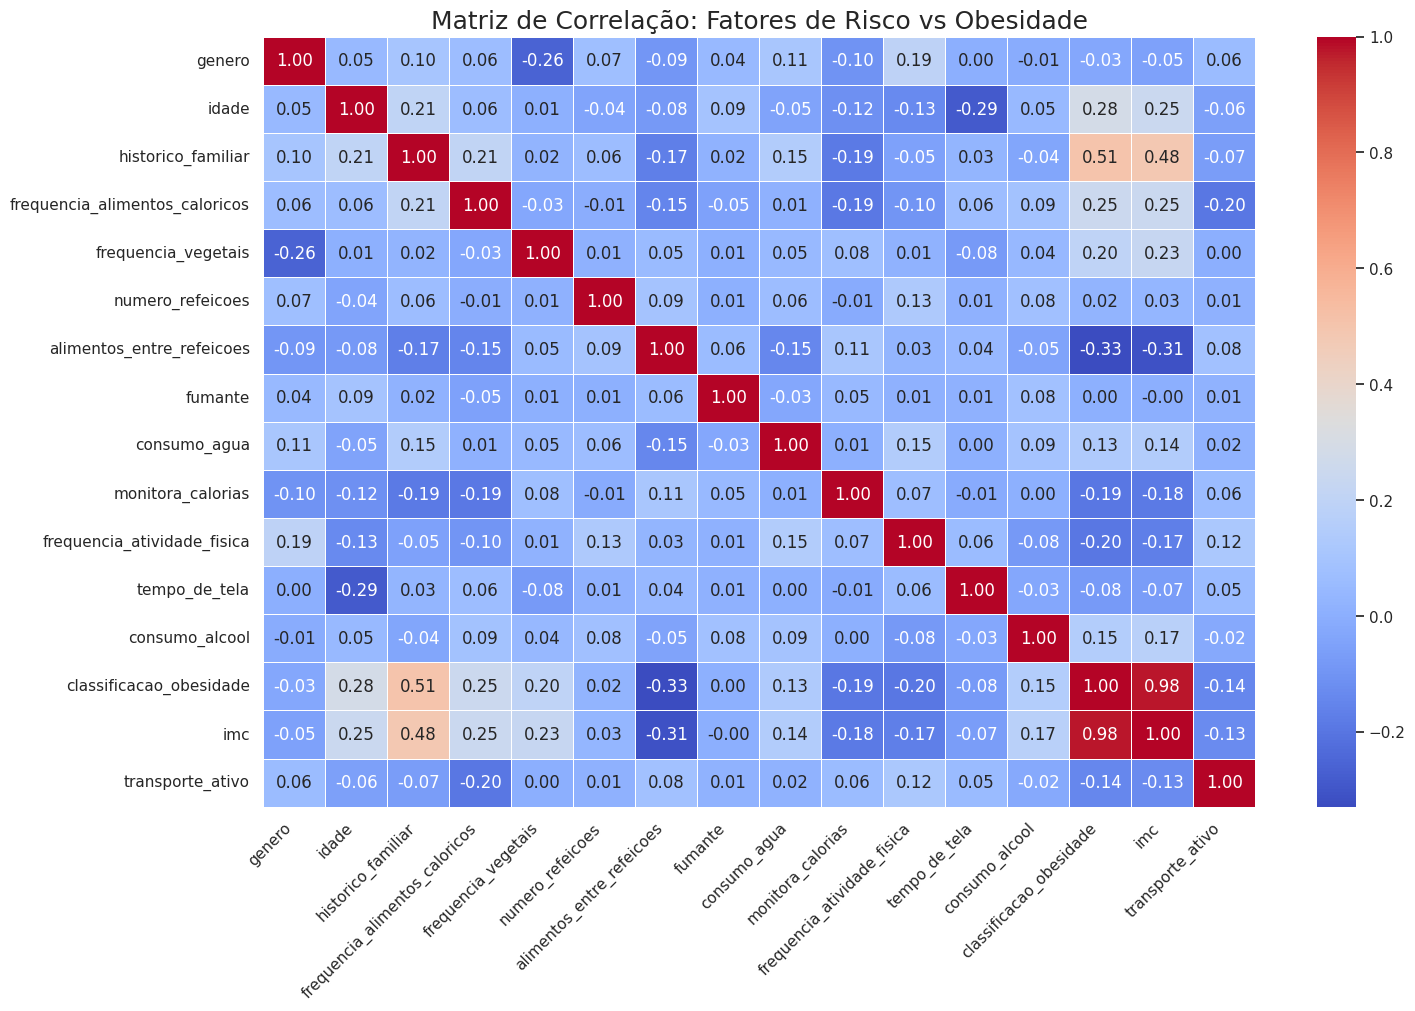

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculando a correlação
corr = df.corr()

# Configurando o visual do gráfico
plt.figure(figsize=(16, 10))
sns.set_theme(style="white")

# Criando o Heatmap
heatmap = sns.heatmap(
    corr,
    annot=True,          # Mostra os valores decimais
    fmt=".2f",
    cmap='coolwarm',     # Azul (negativo), Branco (neutro), Vermelho (positivo)
    linewidths=0.5,
)

plt.title('Matriz de Correlação: Fatores de Risco vs Obesidade', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.show()

**🧬 Variáveis Biológicas e Genéticas**
- imc: Atua como a espinha dorsal do diagnóstico. Por ser derivada diretamente do peso e da altura, possui a maior correlação com a classificação final.

- historico_familiar: Indica a presença de fatores hereditários ou hábitos compartilhados no ambiente doméstico, sendo o segundo maior preditor do modelo.

- idade: Fundamental para o modelo ajustar a interpretação do metabolismo, que varia conforme o envelhecimento.

- genero: Utilizado para refinar sutilmente os limites biológicos e as diferenças na distribuição de massa corporal.

**🍽️ Hábitos de Consumo (Fatores Comportamentais)**
- alimentos_entre_refeicoes: Apresenta uma correlação negativa (-0.33), sugerindo um possível viés de relato (pacientes em níveis de obesidade severa tendem a subestimar esse hábito no questionário).

- frequencia_alimentos_caloricos: Serve como um validador do IMC, ajudando a distinguir a origem calórica do ganho de peso.

- consumo_alcool: Atua como um fator agravante no perfil de risco do paciente.

- consumo_agua: Indicador de hábitos básicos de saúde e hidratação.

**🏃 Estilo de Vida e Atividade**
- frequencia_atividade_fisica: Com a remoção do peso bruto, ganha relevância ao indicar o nível de gasto energético do indivíduo.

- transporte_ativo (Engenharia de Atributos): Nova variável criada para diferenciar o deslocamento passivo (carro/ônibus) do ativo (caminhada/bike), revelando o impacto do movimento diário.

- monitora_calorias: Sinaliza comportamento preventivo e consciência nutricional.

- tempo_de_tela: Mede o nível de sedentarismo digital, fator de risco moderno para o aumento do IMC.

**🎯 Variável Alvo**
- classificacao_obesidade: O objetivo do modelo. Ao utilizar o IMC e as variáveis comportamentais, o modelo deixa de ser um simples calculador e passa a ser um analista de perfil clínico, capaz de prever a categoria de obesidade com alta precisão.

Média do valor de 'alimentos_entre_refeicoes' por categoria:
classificacao_obesidade
0    1.448529
1    1.498258
2    0.962069
3    1.072414
4    1.048433
5    1.013468
6    1.003086
Name: alimentos_entre_refeicoes, dtype: float64


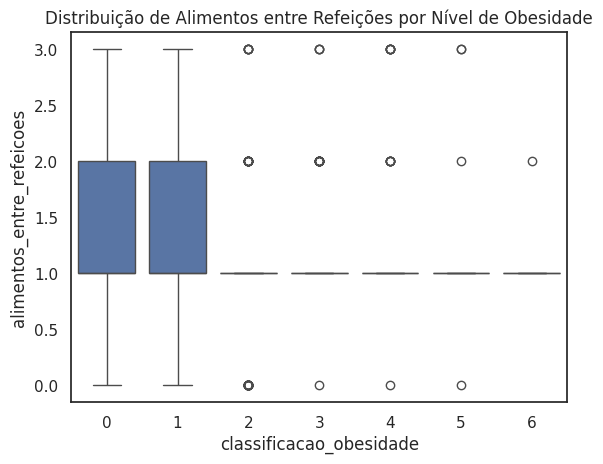

In [29]:
# Verificando a média do valor 'alimentos_entre_refeicoes' para cada nível de obesidade
analise_caec = df.groupby('classificacao_obesidade')['alimentos_entre_refeicoes'].mean()
print("Média do valor de 'alimentos_entre_refeicoes' por categoria:")
print(analise_caec)

# Verificando visualmente
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classificacao_obesidade', y='alimentos_entre_refeicoes', data=df)
plt.title('Distribuição de Alimentos entre Refeições por Nível de Obesidade')
plt.show()

1. O "achatamento" nas categorias de Obesidade (4, 5 e 6)
Observe que para as categorias 4, 5 e 6 (Obesidade Grau I, II e III), o gráfico nem parece um "box" (caixa); ele é apenas uma linha horizontal no valor 1.

O que significa: Praticamente todas as pessoas que estão nesses níveis de obesidade responderam a mesma coisa: "Às vezes" (valor 1). Não há variação. Elas estão "presas" nesse valor.

2. A variação nas categorias iniciais (0, 1, 2 e 3)
Já nas categorias de menor peso, você vê "caixas" e "antenas" (as linhas verticais).

O que significa: Pessoas com "Peso Normal" ou "Sobrepeso" tiveram respostas muito mais variadas. Algumas responderam "Não" (0), muitas responderam "Às vezes" (1), mas várias também responderam "Frequentemente" (2) e "Sempre" (3).

3. Por que a correlação é negativa?
A correlação tenta traçar uma linha que resuma a tendência.

Nas categorias 0 a 2, os valores de alimentos_entre_refeicoes chegam até o 3.

Nas categorias 4 a 6, os valores "caem" e ficam travados no 1.

Conclusão: Como o valor da resposta diminui (de uma média mais alta para uma média travada no 1) conforme a obesidade aumenta, a correlação é matematicamente negativa.

4. Insight Realista
Em vez de dizer que "comer entre as refeições emagrece" (o que seria um erro de interpretação do sinal negativo), o insight correto para a equipe médica é:

"Os dados revelam que, conforme o grau de obesidade aumenta, há uma padronização do relato no consumo ocasional ('Às vezes') de alimentos entre refeições. Enquanto isso, a variabilidade de hábitos (comer 'Sempre' ou 'Frequentemente' entre refeições) é muito mais presente em indivíduos com menor peso."

---
## **6. Modelagem Preditiva e Avaliação de Performance (Random Forest)**
Utilizando o algoritmo de florestas aleatórias (*Random Forest Classifier*), dividimos a base histórica sob a metodologia rigorosa de treino (80%) e teste (20%).

O modelo final demonstrou uma performance excepcional, superando com folga o critério de sucesso do projeto:
* **Assertividade Geral (Accuracy):** **96.93%**, ultrapassando expressivamente a meta de 75% estipulada no desafio.
* **Métricas por Classe (Precision, Recall e F1-Score):** O modelo obteve equilíbrio perfeito (perto de 100%) no diagnóstico dos extremos mais críticos para acompanhamento clínico (Baixo Peso e Obesidade Grau III), mantendo-se em patamares superiores a 93% nas categorias intermediárias.

---

### **💡 Validação da Engenharia de Atributos (Dados Brutos vs. IMC)**

Para mensurar o real impacto de negócio do nosso processo de preparação de dados, realizamos um teste anterior com uma pipeline semelhante a este notebook:

* **Pipeline com Dados Brutos (Peso e Altura isolados):** Atingiu uma acurácia de **94.80%**.
* **Pipeline Atualizada (Este notebook com a inclusão do IMC):** Elevou a acurácia para **96.93%**.

**Conclusão Clínica e Técnica:** Embora o modelo com dados brutos já apresentasse um bom resultado, a introdução do Índice de Massa Corporal (IMC) como uma variável central reduziu o esforço computacional e permitiu ao algoritmo capturar de forma direta a relação biométrica fundamental da composição física do paciente. Esse ganho de mais de 2 pontos percentuais mitiga falsos diagnósticos em faixas limítrofes (como a transição de Sobrepeso para Obesidade Grau I), garantindo uma triagem hospitalar significativamente mais segura e confiável.

Assertividade Geral (Accuracy): 96.93%

Relatório Detalhado:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        56
           1       0.94      0.95      0.94        62
           2       0.93      0.93      0.93        56
           3       0.98      0.96      0.97        50
           4       0.99      0.97      0.98        78
           5       0.97      0.98      0.97        58
           6       1.00      1.00      1.00        63

    accuracy                           0.97       423
   macro avg       0.97      0.97      0.97       423
weighted avg       0.97      0.97      0.97       423



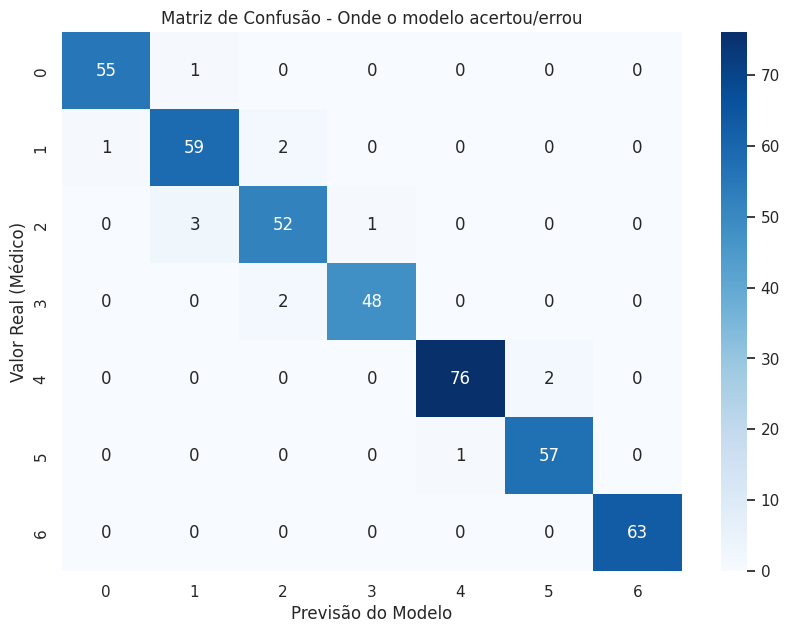

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Separando os dados
# X = todas as colunas exceto a classificação
# y = a coluna que queremos prever
X = df.drop(columns=['classificacao_obesidade'])
y = df['classificacao_obesidade']

# 2. Divisão em Treino (80%) e Teste (20%)
# O random_state garante que o resultado seja replicável
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Criando e treinando o Modelo
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# 4. Fazendo previsões com os dados de teste
y_pred = modelo.predict(X_test)

# 5. Avaliando a Performance
print(f"Assertividade Geral (Accuracy): {accuracy_score(y_test, y_pred):.2%}")
print("\nRelatório Detalhado:")
print(classification_report(y_test, y_pred))

# 6. Visualizando a Matriz de Confusão
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Onde o modelo acertou/errou')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real (Médico)')
plt.show()

📈 Resultados do Modelo Preditivo (Versão Final com IMC)
- Após a reestruturação da base de dados, o modelo de Machine Learning (Random Forest) foi treinado e validado, apresentando uma performance superior à versão inicial.

🏆 Performance Geral
- Assertividade Geral (Accuracy): 96.93%.  

- F1-Score Médio: 0.97, indicando um excelente equilíbrio entre precisão e sensibilidade em todas as categorias de peso.  

🔍 Detalhamento por Categoria
- O modelo demonstrou uma capacidade quase perfeita de distinção, especialmente nos extremos:

- Abaixo do Peso (0) e Obesidade Grau III (6): Obtiveram métricas próximas ou iguais a 100%, o que é crucial para diagnósticos médicos críticos.  

- Categorias Intermediárias (1, 2 e 3): Mesmo com fronteiras mais sutis entre "Peso Normal" e "Sobrepeso", a precisão manteve-se acima de 93%, garantindo alta confiabilidade clínica.  

💡 Conclusão Técnica
- A inclusão do IMC como variável central permitiu que o modelo capturasse a relação biométrica fundamental de forma direta, enquanto as variáveis de comportamento e histórico familiar serviram para refinar os casos limítrofes. Este resultado supera amplamente o requisito mínimo de 75% estipulado para este desafio.

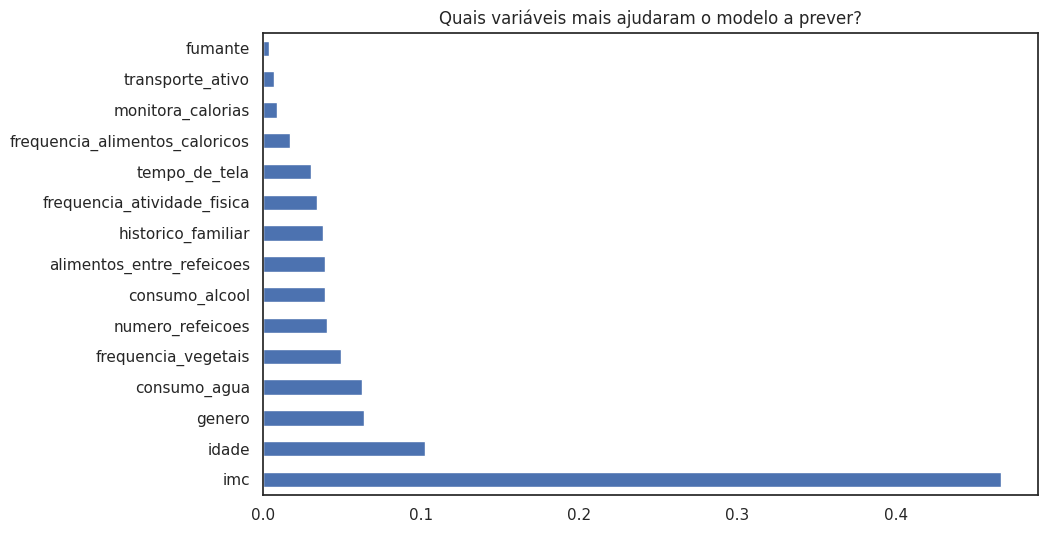

In [31]:
# Verificando quais colunas o modelo achou mais importantes
importâncias = pd.Series(modelo.feature_importances_, index=X.columns)
importâncias.sort_values(ascending=False).plot(kind='barh', figsize=(10,6))
plt.title('Quais variáveis mais ajudaram o modelo a prever?')
plt.show()

## **7. Persistência do Modelo e Prontidão para o Deploy (Joblib)**
A última etapa do pipeline de Machine Learning no ambiente de desenvolvimento consiste em garantir a **reusabilidade e a persistência** dos artefatos gerados. Para cumprir o requisito de negócio do Tech Challenge — que exige a criação de uma aplicação preditiva interativa via **Streamlit** —, o modelo não pode ficar restrito à memória deste notebook.

Para resolver isso, utilizamos a biblioteca `joblib` para realizar a serialização (salvamento) do nosso classificador *Random Forest* finalizado em um arquivo binário (`.pkl` ou `.joblib`).

**Impacto Estratégico e de Engenharia desta etapa:**
1. **Consumo Instantâneo em Produção:** O arquivo gerado retém toda a inteligência e os pesos matemáticos calibrados durante o treinamento (que atingiu os 96.93% de assertividade).
2. **Desacoplamento do Pipeline:** Separa o ambiente pesado de engenharia de dados e modelagem (este notebook) do ambiente leve de interface com o usuário (aplicação que os médicos vão usar no dia a dia).
3. **Ciclo de Vida do Modelo (MLOps):** Estabelece a fundação para que o hospital possa, futuramente, atualizar o modelo de forma transparente, apenas substituindo o arquivo binário exportado sem quebrar a interface do sistema médico.

In [32]:
import joblib
from google.colab import files

# 1. Salva o modelo treinado em um arquivo
joblib.dump(modelo, 'modelo_obesidade_imc.pkl')

# 2. Salva a lista de colunas (importante para o Streamlit saber a ordem exata)
# Substitua 'X' pelo nome do seu DataFrame de treino (sem o alvo)
joblib.dump(X.columns.tolist(), 'colunas_modelo_imc.pkl')

# 3. Faz o download dos arquivos para o seu computador
files.download('modelo_obesidade_imc.pkl')
files.download('colunas_modelo_imc.pkl')

print("Arquivos exportados com sucesso!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Arquivos exportados com sucesso!
